In [1]:
import re,os, sys
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from scipy.interpolate import griddata
from scipy import stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')


# 设置中文字体 (matplotlib)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

from matplotlib import colors as mcolors

# 获取所有基础颜色和CSS4颜色
all_colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)

print('库加载完成')

库加载完成


In [2]:


colors = []
# 打印所有颜色名称
for name, hex_value in all_colors.items():
    # print(f"{name}: {hex_value}")
    colors.append(name)
len(colors)

156

In [8]:

root_path = "./"
shuffix = ".txt"

pattern = re.compile(
    r"bat:(\d+)mV, curr:(\d+)mA, ntc:(\d+)R,\s*RMP:(\d+), duty:(\d+), vbemf:(\d+), bat_level:(\d+)"
)

files_list = [os.path.join(root_path, n) for n in os.listdir(root_path) if n.endswith(shuffix) and not n.startswith("~$")]

files_list


['./3_1_wet_shaving_20260813.txt',
 './5_1_wet_shaving_20260810.txt',
 './5_2_pre_shaving_20260813.txt',
 './5_2_wet_shaving_20260813.txt']

In [47]:
name_titles = ['Vbat', 'I', 'ntc', 'RPM',  'duty', 'BEMF', 'bat_num']     

def safe_open_lines(path):
    for enc in ['utf-8', 'gbk', 'gb2312', 'latin1']:
        try:
            with open(path, 'r', encoding=enc) as f:
                return f.readlines()
        except UnicodeDecodeError:
            continue
    # 全部失败就强制忽略错误
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        return f.readlines()


rows = []

pattern = re.compile(
    r"bat:(\d+)mV, curr:(\d+)mA, ntc:(\d+)R,\s*RMP:(\d+), duty:(\d+), vbemf:(\d+), bat_level:(\d+)"
)
pattern_5 = re.compile(
    r"bat:(\d+)mV, curr:(\d+)mA, ntc:(\d+)R, adj:(\d+),\s*RMP:(\d+), duty:(\d+), vbemf:(\d+), bat_level:(\d+)"

    # bat:4060mV, curr:1060mA, ntc:7619R, adj:0, RMP:12608, duty:577, vbemf:840, bat_level:100, is_use_emergency_flag=0 
)

 

# for line in safe_open_lines(files_list[3]):
with open(files_list[1], "r", encoding="utf-8", errors="ignore") as f:

    for line in f:
        line = line.strip()
        match = pattern_5.search(line)
        if match:

            Vbat = int(match.group(1))
            I = int(match.group(2))
            ntc = int(match.group(3))
            rpm = int(match.group(4))
            duty = int(match.group(5))
            Vbemf = int(match.group(6))
            bat_num = int(match.group(7))

            rows.append(
                {
                    name_titles[0] : Vbat,
                    name_titles[1] : I,
                    name_titles[2] : ntc,
                    name_titles[3] : rpm,
                    name_titles[4] : duty,
                    name_titles[5] : Vbemf,
                    name_titles[6] : bat_num,

                }
            )


# 构建DataFrame
df = pd.DataFrame(rows)

df.info

<bound method DataFrame.info of       Vbat     I   ntc  RPM   duty  BEMF  bat_num
0     4066   980  7634    0  12608   560      732
1     4060  1060  7619    0  12608   577      840
2     4058  1080  7624    0  12608   577      895
3     4060  1040  7619    0  12608   556      893
4     4060   980  7619    0  12608   540      899
...    ...   ...   ...  ...    ...   ...      ...
1166  3854  1680  4413    0  14447   710      420
1167  3854  1680  4413    0  14447   710      421
1168  3854  1680  4413    0  14447   710      420
1169  3856  1680  4417    0  14447   710      424
1170  3854  1680  4413    0  14447   710      425

[1171 rows x 7 columns]>

In [41]:

with open(files_list[2], "r", encoding="utf-8", errors="ignore") as f:

    for line in f:
        line = line.strip()
        # print(line)
        match = pattern.search(line)
        if match:
            print(line)



# plt.figure(figsize=(12,7))
# for i, name in enumerate(name_titles):

#     plt.subplot(i)
#     plt.grid(True)
#     plt.plot(df[name_titles[i]], label=f"{name_titles[i]}")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()


提取到有效数据行数： 583


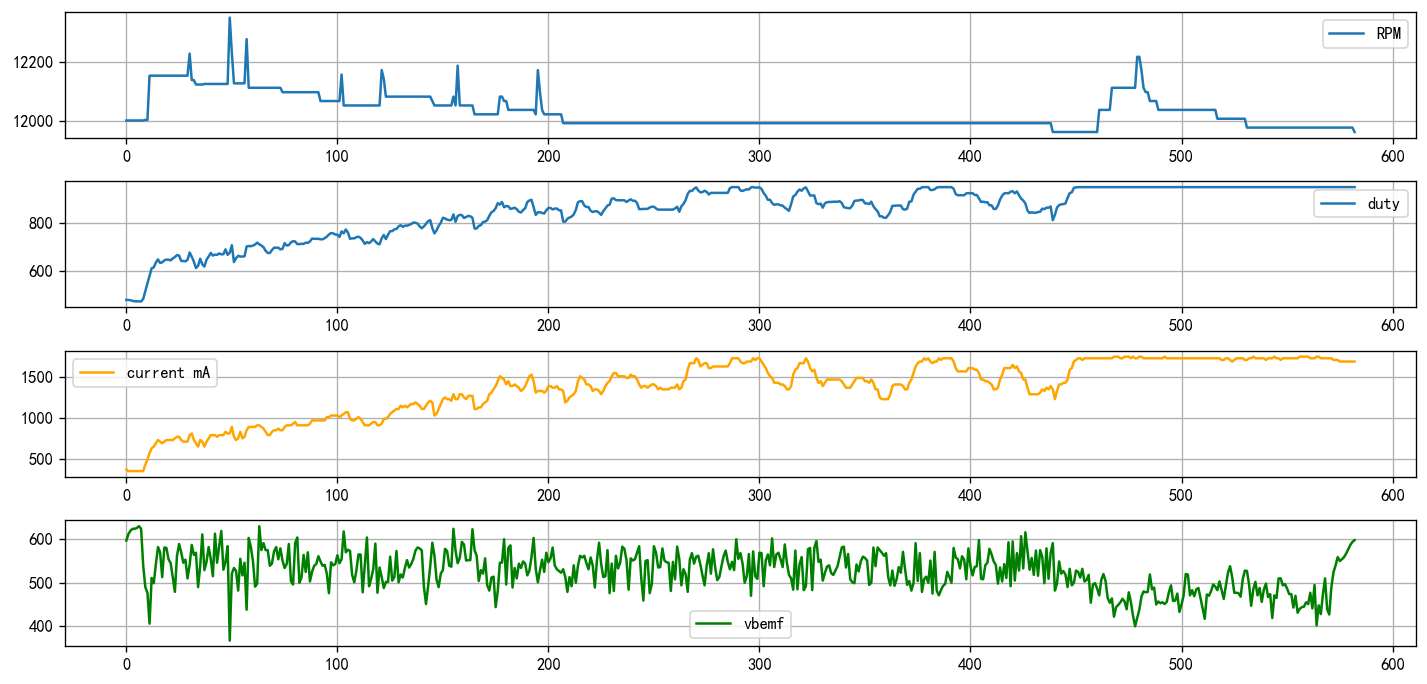

In [20]:

print("提取到有效数据行数：", len(df))
plt.figure(figsize=(12,7))
plt.subplot(511)
plt.plot(df["RPM"], label="RPM")

plt.legend()
plt.grid(True)
plt.subplot(512)
plt.plot(df["duty"], label="duty")
plt.legend()
plt.grid(True)

plt.subplot(513)
plt.plot(df["I"], color="orange", label="current mA")
plt.legend()
plt.grid(True)
plt.subplot(514)
plt.plot(df["BEMF"], color="green", label="vbemf")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

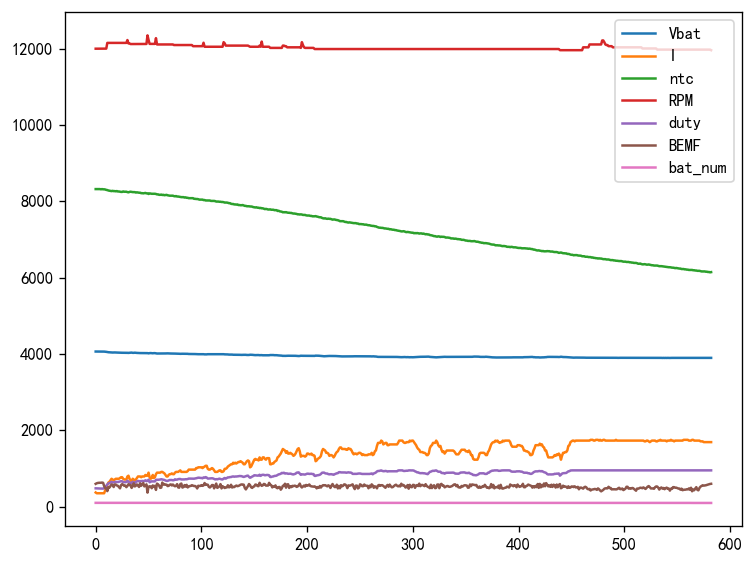

In [21]:


df.plot()
plt.tight_layout()
plt.show()

In [53]:

motor_3_head = """
task_idle highWater:12
*enter task_motor!
*enter task_dyn_reg!
adc_temp:2058, vref:1255 mV
pwm output enable!
bat:4064mV, curr:370mA, ntc:8321R,  RMP:12000, duty:479, vbemf:597, bat_level:99, rpm_step:0, duty=479 
bat:4064mV, curr:350mA, ntc:8321R,  RMP:12000, duty:479, vbemf:612, bat_level:99, rpm_step:0, duty=479 
bat:4064mV, curr:350mA, ntc:8321R,  RMP:12000, duty:477, vbemf:620, bat_level:99, rpm_step:0, duty=477 
bat:4064mV, curr:350mA, ntc:8321R,  RMP:12000, duty:475, vbemf:624, bat_level:99, rpm_step:0, duty=475 
bat:4064mV, curr:350mA, ntc:8321R,  RMP:12000, duty:473, vbemf:624, bat_level:99, rpm_step:0, duty=473 
bat:4062mV, curr:350mA, ntc:8315R,  RMP:12000, duty:473, vbemf:626, bat_level:99, rpm_step:0, duty=473 
bat:4064mV, curr:350mA, ntc:8321R,  RMP:12000, duty:473, vbemf:630, bat_level:99, rpm_step:0, duty=473 
bat:4062mV, curr:350mA, ntc:8315R,  RMP:12000, duty:472, vbemf:624, bat_level:99, rpm_step:0, duty=472 
bat:4062mV, curr:350mA, ntc:8315R,  RMP:12000, duty:483, vbemf:539, bat_level:99, rpm_step:0, duty=483 
bat:4060mV, curr:430mA, ntc:8310R,  RMP:12002, duty:516, vbemf:490, bat_level:99, rpm_step:0, duty=516 
bat:4056mV, curr:490mA, ntc:8300R,  RMP:12002, duty:548, vbemf:477, bat_level:99, rpm_step:0, duty=548 
bat:4050mV, curr:570mA, ntc:8295R,  RMP:12152, duty:580, vbemf:406, bat_level:99, rpm_step:0, duty=580 
bat:4046mV, curr:630mA, ntc:8284R,  RMP:12152, duty:611, vbemf:511, bat_level:99, rpm_step:0, duty=611 
bat:4044mV, curr:650mA, ntc:8279R,  RMP:12152, duty:615, vbemf:499, bat_level:99, rpm_step:0, duty=615 
bat:4042mV, curr:690mA, ntc:8274R,  RMP:12152, duty:635, vbemf:543, bat_level:99, rpm_step:0, duty=635 
bat:4040mV, curr:730mA, ntc:8268R,  RMP:12152, duty:648, vbemf:582, bat_level:99, rpm_step:0, duty=648 
bat:4038mV, curr:710mA, ntc:8275R,  RMP:12152, duty:633, vbemf:570, bat_level:99, rpm_step:0, duty=633 
bat:4040mV, curr:690mA, ntc:8268R,  RMP:12152, duty:636, vbemf:513, bat_level:99, rpm_step:0, duty=636 
motor_sta.is_control_duty_scan_freq = 0 remove restrict!

bat:4040mV, curr:710mA, ntc:8268R,  RMP:12152, duty:644, vbemf:581, bat_level:99, rpm_step:0, duty=644 
bat:4038mV, curr:730mA, ntc:8263R,  RMP:12152, duty:647, vbemf:580, bat_level:99, rpm_step:0, duty=647 
bat:4036mV, curr:730mA, ntc:8269R,  RMP:12152, duty:647, vbemf:554, bat_level:99, rpm_step:0, duty=647 
bat:4036mV, curr:730mA, ntc:8258R,  RMP:12152, duty:644, vbemf:545, bat_level:99, rpm_step:0, duty=644 
bat:4036mV, curr:730mA, ntc:8258R,  RMP:12152, duty:652, vbemf:513, bat_level:99, rpm_step:0, duty=652 
"""


motor_5_head = """
*exit standby-mode! 
task_idle highWater:21
adc_module_init comp. 
*enter task_motor!
*enter task_dyn_reg!
pwm output enable!
bat:3772mV, curr:1420mA, ntc:6855R, adj:0, RMP:16267, duty:650, vbemf:215, bat_level:90, is_use_emergency_flag=0 
bat:3770mV, curr:1420mA, ntc:6850R, adj:0, RMP:16267, duty:650, vbemf:209, bat_level:90, is_use_emergency_flag=0 
bat:3770mV, curr:1420mA, ntc:6850R, adj:0, RMP:16267, duty:650, vbemf:206, bat_level:90, is_use_emergency_flag=0 
bat:3768mV, curr:1440mA, ntc:6854R, adj:0, RMP:16267, duty:650, vbemf:200, bat_level:90, is_use_emergency_flag=0 
bat:3768mV, curr:1440mA, ntc:6854R, adj:0, RMP:16267, duty:650, vbemf:201, bat_level:90, is_use_emergency_flag=0 
bat:3768mV, curr:1420mA, ntc:6854R, adj:0, RMP:16267, duty:650, vbemf:198, bat_level:90, is_use_emergency_flag=0 
bat:3766mV, curr:1420mA, ntc:6849R, adj:0, RMP:16267, duty:650, vbemf:196, bat_level:90, is_use_emergency_flag=0 
bat:3764mV, curr:1440mA, ntc:6845R, adj:0, RMP:16267, duty:650, vbemf:194, bat_level:90, is_use_emergency_flag=0 
bat:3764mV, curr:1440mA, ntc:6845R, adj:0, RMP:16267, duty:650, vbemf:194, bat_level:90, is_use_emergency_flag=0 
bat:3764mV, curr:1440mA, ntc:6845R, adj:0, RMP:16267, duty:650, vbemf:191, bat_level:90, is_use_emergency_flag=0 
bat:3764mV, curr:1440mA, ntc:6845R, adj:0, RMP:16267, duty:650, vbemf:193, bat_level:90, is_use_emergency_flag=0 
motor_sta.is_control_duty_scan_freq = 0 remove restrict!

bat:3762mV, curr:1440mA, ntc:6840R, adj:0, RMP:16267, duty:654, vbemf:192, bat_level:90, is_use_emergency_flag=0 
bat:3758mV, curr:1500mA, ntc:6839R, adj:0, RMP:16267, duty:686, vbemf:196, bat_level:90, is_use_emergency_flag=0 
bat:3748mV, curr:1660mA, ntc:6823R, adj:0, RMP:16267, duty:718, vbemf:197, bat_level:90, is_use_emergency_flag=0 
bat:3736mV, curr:1820mA, ntc:6803R, adj:0, RMP:16267, duty:750, vbemf:196, bat_level:90, is_use_emergency_flag=0 
bat:3726mV, curr:2000mA, ntc:6787R, adj:0, RMP:16267, duty:782, vbemf:194, bat_level:90, is_use_emergency_flag=0 
bat:3714mV, curr:2180mA, ntc:6767R, adj:0, RMP:16267, duty:814, vbemf:193, bat_level:90, is_use_emergency_flag=0 
bat:3702mV, curr:2360mA, ntc:6755R, adj:0, RMP:16267, duty:846, vbemf:191, bat_level:90, is_use_emergency_flag=0 
bat:3692mV, curr:2500mA, ntc:6740R, adj:0, RMP:16267, duty:850, vbemf:190, bat_level:90, is_use_emergency_flag=0 
bat:3692mV, curr:2500mA, ntc:6740R, adj:0, RMP:16267, duty:850, vbemf:188, bat_level:90, is_use_emergency_flag=0 
bat:3692mV, curr:2500mA, ntc:6740R, adj:0, RMP:16267, duty:850, vbemf:187, bat_level:90, is_use_emergency_flag=0 
"""





In [52]:
# -*- coding: utf-8 -*-
"""
1163 剃须刀湿剃 - 串口数据批量分析脚本
数据格式: bat:XXXXmV, curr:XXXXmA, ntc:XXXXR, RMP:XXXX, duty:XXX, vbemf:XXX, bat_level:XX

使用方法:
    python batch_wetshave_analysis.py                     # 处理当前目录全部 .txt
    python batch_wetshave_analysis.py "D:\data\log1.txt"  # 处理单个文件
    python batch_wetshave_analysis.py "D:\data_folder"    # 处理某目录全部 .txt
"""
import os
import sys
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# =============== 全局配置 ===============
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 串口日志正则（与 notebook 保持一致）
LOG_PATTERN_3 = re.compile(
    # r"bat:(\d+)mV, curr:(\d+)mA, ntc:(\d+)R,\s*RMP:(\d+), duty:(\d+), vbemf:(\d+), bat_level:(\d+)"
    r"bat:(\d+)mV, curr:(\d+)mA, ntc:(\d+)R,\s*RMP:(\d+), duty:(\d+), vbemf:(\d+), bat_level:(\d+)"
)

LOG_PATTERN_5 = re.compile(
    r"bat:(\d+)mV, curr:(\d+)mA, ntc:(\d+)R, adj:(\d+),\s*RMP:(\d+), duty:(\d+), vbemf:(\d+), bat_level:(\d+)"
)

NTC_TABLE = [
    ( 0, 32371), ( 5, 25531), ( 8, 22028),
    (15, 15760), (18, 13710), (35,  6516),
    (42,  4900), (45,  4352), (55,  2973),
    (60,  2447),
]
# 过温阈值（用于图上高亮着色）
TEMP_WARN = 45.0   # °C 橙色
TEMP_ALARM = 55.0  # °C 红色


CHANNELS_3 = [
    ('Vbat',    '电压 (mV)',      colors[0]),
    ('I',       '电流 (mA)',      colors[1]),
    ('ntc',     'NTC (R)',        colors[2]),
    ('RPM',     '转速 (RPM)',     colors[3]),
    ('duty',    '占空比',         colors[4]),
    ('BEMF',    '反电动势',       colors[5]),
    ('bat_num', '电量等级 (%)',   colors[6]),
]
CHANNELS_5 = [
    ('Vbat',    '电压 (mV)',      colors[0]),
    ('I',       '电流 (mA)',      colors[1]),
    ('ntc',     'NTC (R)',        colors[2]),
    ('adj',     'step',        colors[7]),
    ('RPM',     '转速 (RPM)',     colors[3]),
    ('duty',    '占空比',         colors[4]),
    ('BEMF',    '反电动势',       colors[5]),
    ('bat_num', '电量等级 (%)',   colors[6]),
]

COL_NAMES_3 = [c[0] for c in CHANNELS_3]
COL_NAMES_5 = [c[0] for c in CHANNELS_5]


def parse_log_file(file_path, is_flag=False):
    """解析单个串口日志文件 -> DataFrame"""
    rows = []
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            if is_flag:
                m = LOG_PATTERN_3.search(line)
                if m:
                    try:
                        rows.append({
                            COL_NAMES_3[0]: int(m.group(1)),  # Vbat
                            COL_NAMES_3[1]: int(m.group(2)),  # I
                            COL_NAMES_3[2]: int(m.group(3)),  # ntc
                            COL_NAMES_3[3]: int(m.group(4)),  # RPM
                            COL_NAMES_3[4]: int(m.group(5)),  # duty
                            COL_NAMES_3[5]: int(m.group(6)),  # BEMF
                            COL_NAMES_3[6]: int(m.group(7)),  # bat_num
                        })
                    except ValueError:
                        continue
            else:
                m = LOG_PATTERN_5.search(line)
                if m:
                    try:
                        rows.append({
                            COL_NAMES_5[0]: int(m.group(1)),  # Vbat
                            COL_NAMES_5[1]: int(m.group(2)),  # I
                            COL_NAMES_5[2]: int(m.group(3)),  # ntc
                            COL_NAMES_5[3]: int(m.group(4)),  # adj
                            COL_NAMES_5[4]: int(m.group(5)),  # RPM
                            COL_NAMES_5[5]: int(m.group(6)),  # duty
                            COL_NAMES_5[6]: int(m.group(7)),  # BEMF
                            COL_NAMES_5[7]: int(m.group(8)),  # bat_num
                        })
                    except ValueError:
                        continue
    df = pd.DataFrame(rows)
    return df, line_no, len(rows)


def discover_txt_files(target):
    """根据输入（文件/目录/无参数）返回要处理的 txt 文件列表"""
    # if target is None:
    #     target = os.path.dirname(os.path.abspath(__file__))
    if os.path.isfile(target):
        return [target]
    assert os.path.isdir(target), f"路径不存在: {target}"
    files = [os.path.join(target, n)
             for n in os.listdir(target)
             if n.lower().endswith('.txt') and not n.startswith('~$')]
    files.sort()
    return files


# =============== 绘图函数 ===============

def plot_single_file_timeseries(df, file_label, save_path, is_flag):
    """
    单文件 7 通道时间序列图（4行2列，修复 notebook 里 subplot(0) 的bug）
    """
    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(4, 2, hspace=0.38, wspace=0.28)
    axes = [
        fig.add_subplot(gs[0, 0]),  # Vbat
        fig.add_subplot(gs[0, 1]),  # I
        fig.add_subplot(gs[1, 0]),  # ntc
        fig.add_subplot(gs[1, 1]),  # RPM
        fig.add_subplot(gs[2, 0]),  # duty
        fig.add_subplot(gs[2, 1]),  # BEMF
        # fig.add_subplot(gs[3, :]),  # bat_num (占满一整行)
    ]
    t = np.arange(len(df))

    ch = CHANNELS_5
    if is_flag:
        ch = CHANNELS_3

    plot_ch = [c for c in ch if c[0] != 'adj']   # 先移除 adj
    for ax, (col, ylabel, color) in zip(axes, plot_ch):
        # print('11111111', col, ylabel, color)
        # if col == 'adj':
        #     col = 'BEMF'
        #     ylabel = '反电动势'
        # print('22222222', col, ylabel, color)
        vals = df[col].values
        ax.plot(t, vals, color=color, linewidth=1.1, label=col)
        ax.set_xlabel('采样点序号', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9, color=color)
        ax.tick_params(axis='y', labelcolor=color, labelsize=8)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(True, alpha=0.3, linestyle='--')

        # 统计标注（均值 + 最大最小值）
        avg, vmin, vmax = vals.mean(), vals.min(), vals.max()
        ax.axhline(avg, color=color, linestyle=':', linewidth=0.9, alpha=0.8)
        annotation = (f'μ={avg:.1f}\n'
                      f'min={vmin:.0f} @ {vals.argmin()}\n'
                      f'max={vmax:.0f} @ {vals.argmax()}')
        ax.text(0.985, 0.97, annotation, transform=ax.transAxes,
                fontsize=7.5, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec=color, alpha=0.85))

    # 总体标题
    n = len(df)
    duration = ''
    if n > 1:
        # 近似时长：串口一般 10~100Hz，给出秒数估算
        est_sec = n / 20
        duration = f'  ~ {est_sec:.0f}s (@20Hz 估计)'
    fig.suptitle(f'{file_label}\n共 {n:,} 个有效采样点{duration}',
                 fontsize=13, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.975])
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.close()


def plot_correlation_heatmap(df, file_label, save_path, is_flag):
    """7 通道相关性热力图"""
    if len(df) < 10:
        return

    col_name = COL_NAMES_5
    if is_flag:
        col_name = COL_NAMES_3
    corr = df[col_name].corr()
    fig, ax = plt.subplots(figsize=(8, 6.5))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True,
                linewidths=0.5, annot_kws={'size': 9}, ax=ax,
                vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{file_label}  -  通道相关性矩阵', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.close()


def plot_current_vs_rpm(df, file_label, save_path):
    """电流 vs 转速 散点图（剃须刀负载工况关键图）"""
    if len(df) < 10:
        return


    if True:
        fig, axes = plt.subplots(1, 1, figsize=(14, 5), squeeze=False)
        # 占空比-电流-RPM 三维示意（用双轴）
        ax2 = axes[0, 0]
        ax2b = ax2.twinx()
        t = np.arange(len(df))
        ax2.plot(t, df['I'], color='#d62728', alpha=0.85, label='电流 I', linewidth=1)
        ax2b.plot(t, df['RPM'], color='g', alpha=0.85, label='转速 RPM', linewidth=1)
        ax2b.plot(t, df['duty'] * (df['RPM'].max() / 1024) if df['duty'].max() <= 1024 else df['duty'],
                color='b', alpha=0.6, label='duty (scaled)', linewidth=0.9, linestyle='--')
        ax2.set_xlabel('采样点')
        ax2.set_ylabel('电流 (mA)', color='#d62728')
        ax2b.set_ylabel('RPM / scaled duty', color='#ff7f0e')
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2b.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
        axes[0, 0].set_title('电流 & 转速 时间序列')
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'{file_label}  -  电流/转速/占空比 联动分析',
                    fontsize=12, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        plt.close()
        
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        # 散点 + 密度
        axes[0].scatter(df['RPM'], df['I'], s=8, alpha=0.4,
                        c=df['duty'], cmap='viridis', linewidths=0)
        sc = axes[0].scatter([], [], c=[], cmap='viridis')
        cbar = fig.colorbar(sc, ax=axes[0])
        cbar.set_label('duty (占空比)', fontsize=9)
        axes[0].set_xlabel('RPM (转速)')
        axes[0].set_ylabel('I (电流 mA)')
        axes[0].set_title('电流-转速散点 (颜色=占空比)')
        axes[0].grid(True, alpha=0.3)

        # 占空比-电流-RPM 三维示意（用双轴）
        ax2 = axes[1]
        ax2b = ax2.twinx()
        t = np.arange(len(df))
        ax2.plot(t, df['I'], color='#d62728', alpha=0.85, label='电流 I', linewidth=1)
        ax2b.plot(t, df['RPM'], color='#ff7f0e', alpha=0.85, label='转速 RPM', linewidth=1)
        ax2b.plot(t, df['duty'] * (df['RPM'].max() / 1024) if df['duty'].max() <= 1024 else df['duty'],
                color='#9467bd', alpha=0.6, label='duty (scaled)', linewidth=0.9, linestyle='--')
        ax2.set_xlabel('采样点')
        ax2.set_ylabel('电流 (mA)', color='#d62728')
        ax2b.set_ylabel('RPM / scaled duty', color='#ff7f0e')
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2b.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
        axes[1].set_title('电流 & 转速 时间序列')
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'{file_label}  -  电流/转速/占空比 联动分析',
                    fontsize=12, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        plt.close()


def plot_multi_file_comparison(dfs_dict, file_labels, output_dir):
    """多文件关键通道对比（RPM, I, Vbat）"""
    if len(dfs_dict) < 2:
        print("  ⓘ 文件少于 2 个，跳过多文件对比图\n")
        return
    print("  [附加] 生成多文件对比图...")

    channels_to_plot = [('RPM', '#ff7f0e'), ('I', '#d62728'), ('Vbat', '#1f77b4')]
    fig, axes = plt.subplots(len(channels_to_plot), 1,
                             figsize=(14, 3.6 * len(channels_to_plot)),
                             sharex=False)
    if len(channels_to_plot) == 1:
        axes = [axes]

    for ax, (ch, color) in zip(axes, channels_to_plot):
        for i, label in enumerate(file_labels):
            df = dfs_dict[label]
            t = np.linspace(0, 100, len(df))  # 归一化到 0~100% 方便对比
            # 平滑
            vals = df[ch].values
            window = max(1, len(vals) // 200)
            if window > 1:
                kernel = np.ones(window) / window
                vals_s = np.convolve(vals, kernel, mode='same')
            else:
                vals_s = vals
            ax.plot(t, vals_s, linewidth=1.1,
                    alpha=0.85, label=f'{label} (n={len(df)})')
        ax.set_ylabel(ch, fontsize=10)
        ax.set_xlabel('归一化时长 (%)', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=7.5, ncol=2, loc='best')
        ax.set_title(f'{ch} 多文件对比（滑动均值平滑）', fontsize=11, fontweight='bold')

    plt.tight_layout()
    path = os.path.join(output_dir, '00_multi_file_comparison.png')
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.close()
    print(f"    ✓ {path}\n")


# =============== 统计 ===============

def build_stats_summary(dfs_dict, file_labels, output_dir):
    """构建所有文件的统计汇总表并保存 CSV"""
    rows = []
    for label in file_labels:
        df = dfs_dict[label]
        r = {'文件': label, '有效采样数': len(df)}
        # print('label=',label)

        ch = CHANNELS_5
        if label[0:1] == '3':
            ch = CHANNELS_3
        for col, _, _ in ch:
            vals = df[col].values
            r[f'{col}_mean'] = vals.mean()
            r[f'{col}_std'] = vals.std()
            r[f'{col}_min'] = vals.min()
            r[f'{col}_max'] = vals.max()
            r[f'{col}_median'] = np.median(vals)
            # 剃须刀关键指标：RPM 跌落（max - min）、电流均值（代表负载）
        if len(df) > 50:
            r['RPM_drop'] = df['RPM'].max() - df['RPM'].min()
            r['I_mean_load'] = df['I'].mean()
        rows.append(r)

    stats_df = pd.DataFrame(rows)
    csv_path = os.path.join(output_dir, 'wetshave_stats_summary.csv')
    stats_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"  ✓ 统计汇总: {csv_path}")

    # 同时保存一份"关键指标速览"打印
    print("\n" + "=" * 72)
    print("  关键指标速览 (RPM均值 / RPM跌落 / 电流均值)")
    print("=" * 72)
    cols_show = ['文件', '有效采样数']
    if 'RPM_mean' in stats_df.columns:
        cols_show += ['RPM_mean', 'RPM_min', 'RPM_max']
    if 'RPM_drop' in stats_df.columns:
        cols_show += ['RPM_drop']
    if 'I_mean' in stats_df.columns:
        cols_show += ['I_mean', 'I_max']
    cols_show += [c for c in ['Vbat_mean', 'Vbat_min'] if c in stats_df.columns]
    with pd.option_context('display.float_format', '{:.1f}'.format,
                           'display.max_columns', None,
                           'display.width', 140):
        print(stats_df[cols_show].to_string(index=False))
    print()


# =============== 主流程 ===============

def main():
    # target = sys.argv[1] if len(sys.argv) > 1 else None
    # target = "./"
    # files = discover_txt_files(target)

    root_path = "./"
    shuffix = ".txt"

    pattern = re.compile(
        r"bat:(\d+)mV, curr:(\d+)mA, ntc:(\d+)R,\s*RMP:(\d+), duty:(\d+), vbemf:(\d+), bat_level:(\d+)"
    )

    files = [os.path.join(root_path, n) for n in os.listdir(root_path) if n.endswith(shuffix) and not n.startswith("~$")]
    print(files)

    if not files:
        print("❌ 未找到任何 .txt 文件")
        sys.exit(1)

    # 输出目录
    base = (os.path.dirname(os.path.abspath(root_path))
            if root_path and os.path.isfile(root_path)
            else os.path.dirname(os.path.abspath(root_path)))
    output_dir = os.path.join(base, 'wetshave_output')
    os.makedirs(output_dir, exist_ok=True)

    print(f"{'='*68}")
    print(f"  1163 湿剃串口批量分析")
    print(f"  待处理: {len(files)} 个 .txt 文件")
    print(f"  输出目录: {output_dir}")
    print(f"{'='*68}\n")

    # Step 1: 批量解析
    print(f"[1/5] 解析文件...")
    dfs_dict = {}
    for index, fp in enumerate(files):
        name = os.path.basename(fp)
        is_3_head = False
        # print(name, (fp), fp[2:3])
        if (fp[2:3]) == '3':
            is_3_head = True
        df, total_lines, valid = parse_log_file(fp, is_flag=is_3_head)
        hit_rate = (valid / total_lines * 100) if total_lines else 0
        status = "✅" if valid > 0 else "⚠️ "
        print(f"  {status} {name:35s}  {valid:>5d}/{total_lines:<5d}行  匹配率 {hit_rate:5.1f}%")
        if valid > 0:
            dfs_dict[name] = df
    if not dfs_dict:
        print("\n❌ 所有文件均未解析到有效数据，正则是否匹配？")
        sys.exit(2)
    file_labels = list(dfs_dict.keys())
    print()

    # Step 2: 统计汇总
    print("[2/5] 生成统计汇总...")
    build_stats_summary(dfs_dict, file_labels, output_dir)

    # Step 3: 单文件时间序列 + 相关图 + I-RPM 图
    print(f"[3/5] 生成单文件时间序列图 ({len(dfs_dict)}个)...")
    for i, label in enumerate(file_labels, 1):
        df = dfs_dict[label]
        safe = label.replace('/', '_').replace('\\', '_')
        # prefix = f"{i:02d}_{safe[:-4]}"
        prefix = safe[:-4]
        # print(prefix)
        is_flag = False

        if prefix[0:1] == '3':
            is_flag = True

        try:
            plot_single_file_timeseries(
                df, label,
                os.path.join(output_dir, f'{prefix}_timeseries.png'), is_flag)

            # plot_correlation_heatmap(
            #     df, label,
            #     os.path.join(output_dir, f'{prefix}_correlation.png'), is_flag)

            # plot_current_vs_rpm(
            #     df, label,
            #     os.path.join(output_dir, f'{prefix}_IRPM.png'))
            print(f"  ✓ [{i}/{len(file_labels)}] {label}")
        except Exception as e:
            print(f"  ✗ [{i}/{len(file_labels)}] {label}  绘图出错: {e}")
    print()

    # Step 4: 多文件对比
    print("[4/5] 多文件对比...")
    plot_multi_file_comparison(dfs_dict, file_labels, output_dir)

    # Step 5: 生成索引 Markdown (可选)
    print("[5/5] 生成索引...")
    md_path = os.path.join(output_dir, '_INDEX.md')
    with open(md_path, 'w', encoding='utf-8') as f:
        f.write("# 1163 湿剃串口批量分析报告  \n\n")
        f.write(f"- 生成时间: {pd.Timestamp.now()}\n")
        f.write(f"- 文件总数: {len(file_labels)}\n\n")
        for i, label in enumerate(file_labels, 1):
            safe = label.replace('/', '_').replace('\\', '_')
            prefix = f"{i:02d}_{safe}"

            is_flag = False
            if safe[0:1] == '3':
                is_flag = True


            f.write(f"\n## {i}. {label}\n\n")
            df = dfs_dict[label]
            f.write(f"- 有效采样: {len(df):,}\n")
            f.write(f"- RPM 范围: {df['RPM'].min():.0f} ~ {df['RPM'].max():.0f}\n")
            f.write(f"- 电流范围: {df['I'].min():.0f} ~ {df['I'].max():.0f} mA\n\n")
            for suffix, title in [('timeseries', '时间序列'),
                                  ('correlation', '相关性'),
                                  ('IRPM', '电流-转速')]:
                fn = f'{prefix}_{suffix}.png'
                f.write(f"### {title}\n\n![]({fn})\n\n")
        if len(file_labels) >= 2:
            f.write("\n## 多文件对比\n\n![](00_multi_file_comparison.png)\n")
    print(f"  ✓ 索引: {md_path}\n")

    print(f"{'='*68}")
    print(f"  ✓ 全部完成！输出目录: {output_dir}")
    print(f"{'='*68}")


if __name__ == '__main__':
    main()

['./3_1_wet_shaving_20260813.txt', './3_2_pre_shaving_20260817.txt', './3_2_wet_shaving_20260817.txt', './5_1_wet_shaving_20260810.txt', './5_2_pre_shaving_20260813.txt', './5_2_wet_shaving_20260813.txt', './5_3_pre_shaving_20260817.txt', './5_3_wet_shaving_20260817.txt']
  1163 湿剃串口批量分析
  待处理: 8 个 .txt 文件
  输出目录: f:\source\code\work\project\linear_motor\B1163\3head\PCB_REV01\3_1163_PCB01_CODE_REV01\test\data\wetshave_output

[1/5] 解析文件...
  ✅ 3_1_wet_shaving_20260813.txt           583/601  行  匹配率  97.0%
  ✅ 3_2_pre_shaving_20260817.txt           110/126  行  匹配率  87.3%
  ✅ 3_2_wet_shaving_20260817.txt           941/977  行  匹配率  96.3%
  ✅ 5_1_wet_shaving_20260810.txt          1171/1197 行  匹配率  97.8%
  ✅ 5_2_pre_shaving_20260813.txt           328/362  行  匹配率  90.6%
  ✅ 5_2_wet_shaving_20260813.txt          1049/1076 行  匹配率  97.5%
  ✅ 5_3_pre_shaving_20260817.txt           321/339  行  匹配率  94.7%
  ✅ 5_3_wet_shaving_20260817.txt          1021/1047 行  匹配率  97.5%

[2/5] 生成统计汇总...
  ✓ 统计汇总: f